# Libraries

In [1]:
import os
from typing import Optional
from pathlib import Path
import ffmpeg
import pandas as pd

In [3]:
annot = pd.read_csv("/home/merci/code/PycharmProjects/cardionix-pipeline/data/DHD/metadata.csv")

In [15]:
for i, label in enumerate(annot.label):
    if 'label' in label or isinstance(label, type(None)):
        annot = annot.drop(index=i)

In [17]:
annot.to_csv("metadata.csv", index=False)

In [10]:
data = data.rename(columns={"fname": "filename"})

data

,filename,label
0,set_b/Btraining_extrastole_127_1306764300147_C...,extrastole
1,set_b/Btraining_extrastole_128_1306344005749_A...,extrastole
2,set_b/Btraining_extrastole_130_1306347376079_D...,extrastole
3,set_b/Btraining_extrastole_134_1306428161797_C...,extrastole
4,set_b/Btraining_extrastole_138_1306762146980_B...,extrastole
...,...,...
171,set_a/__201108222241.wav,NaN
172,set_a/__201108222244.wav,NaN
173,set_a/__201108222247.wav,NaN
174,set_a/__201108222254.wav,NaN


In [17]:
[1 for f in data.filename if os.path.exists(f"../data/archive/set_a/{f}")].__len__()

124

In [18]:
os.listdir("../data/archive/set_a")

['murmur__201101051104.wav',
 'murmur__201101051108.wav',
 'murmur__201101051114.wav',
 'murmur__201101180902.wav',
 'murmur__201102051443.wav',
 'murmur__201102052338.wav',
 'murmur__201103291548.wav',
 'murmur__201104021355.wav',
 'murmur__201104241315.wav',
 'murmur__201104291843.wav',
 'murmur__201106141148.wav',
 'murmur__201108222221.wav',
 'murmur__201108222223.wav',
 'murmur__201108222224.wav',
 'murmur__201108222226.wav',
 'murmur__201108222227.wav',
 'murmur__201108222231.wav',
 'murmur__201108222232.wav',
 'murmur__201108222233.wav',
 'murmur__201108222235.wav',
 'murmur__201108222236.wav',
 'murmur__201108222237.wav',
 'murmur__201108222238.wav',
 'murmur__201108222242.wav',
 'murmur__201108222243.wav',
 'murmur__201108222245.wav',
 'murmur__201108222246.wav',
 'murmur__201108222248.wav',
 'murmur__201108222251.wav',
 'murmur__201108222252.wav',
 'murmur__201108222253.wav',
 'murmur__201108222255.wav',
 'murmur__201108222256.wav',
 'murmur__201108222258.wav',
 'normal__2011

In [55]:
xc = 'normal_noisynormal_270_1309369533040_A.wav'.split("_")



label = ""
for ch in xc:
    if ch.isdigit():
      break
    label += f"{ch}"

label

'normalnoisynormal'

In [64]:
import uuid
f"{uuid.uuid4()}"

'75b9b39d-5ab3-43ee-a66c-213d33a5927a'

In [77]:
from datetime import datetime

f"{datetime.date()}"

TypeError: unbound method datetime.date() needs an argument

In [82]:
import librosa

In [92]:
wave, sr = librosa.load("/home/merci/code/PycharmProjects/cardionix-pipeline/data/archive/set_b/Bunlabelledtest__109_1305653646620_D.wav", sr=None)
librosa.get_duration(y=wave, sr=sr)

4000

In [106]:
def listdir(dirpath: str | Path) -> list[str, ...]:
    data = {
        "filename": [],
        "label": [],
        "duration": [],
        "sr": [],
        "device": [],
        "source": [],
        "date": []
    }


    for i, filename in enumerate(os.listdir(dirpath)):
        now = datetime.now()

        label = filename.split("_")[0].lower()
        new_filename = f"{label}__{uuid.uuid4()}.wav"

        data["filename"].append(new_filename)
        data["label"].append(label)
        data["date"].append(now)
        data["source"].append("https://www.kaggle.com/datasets/kinguistics/heartbeat-sounds")
        data["device"].append("phone - iStethoscope Pro iPhone app")

        _input: str = f"{dirpath}/{filename}"
        _output: str = f"{dirpath}/{new_filename}"

        os.rename(_input, _output)

        wave, sr = librosa.load(_output, sr=None)
        duration = librosa.get_duration(y=wave, sr=sr)
        data["duration"].append(duration)
        data["sr"].append(sr)


    return pd.DataFrame(data)

In [107]:
D1 = listdir("/home/merci/code/PycharmProjects/cardionix-pipeline/data/archive/set_a")

In [104]:
D2 = listdir("/home/merci/code/PycharmProjects/cardionix-pipeline/data/archive/set_b")

In [110]:
DD = pd.concat([D1, D2])
DD

,filename,label,duration,sr,device,source,date
0,murmur__90861319-0927-48cc-94b6-9cd86f00ae8f.wav,murmur,8.884059,44100,phone - iStethoscope Pro iPhone app,https://www.kaggle.com/datasets/kinguistics/he...,2025-02-24 21:05:22.288738
1,murmur__0d38b428-8ce5-4704-8cb9-42eaacb6fd46.wav,murmur,8.884059,44100,phone - iStethoscope Pro iPhone app,https://www.kaggle.com/datasets/kinguistics/he...,2025-02-24 21:05:22.290555
2,murmur__a2536dd9-f423-47ee-a4bf-53b8c08d1e3d.wav,murmur,8.884059,44100,phone - iStethoscope Pro iPhone app,https://www.kaggle.com/datasets/kinguistics/he...,2025-02-24 21:05:22.292277
3,murmur__5975945c-880a-4418-a47e-e7ef76900b89.wav,murmur,8.034422,44100,phone - iStethoscope Pro iPhone app,https://www.kaggle.com/datasets/kinguistics/he...,2025-02-24 21:05:22.293876
4,murmur__b2172d58-4864-4ef0-9239-211d4638e4e2.wav,murmur,6.818934,44100,phone - iStethoscope Pro iPhone app,https://www.kaggle.com/datasets/kinguistics/he...,2025-02-24 21:05:22.295297
...,...,...,...,...,...,...,...
651,normal__2cc85274-5789-42d2-8ca4-feec61244096.wav,normal,2.328750,4000,digital stethoscope - DigiScope,https://www.kaggle.com/datasets/kinguistics/he...,2025-02-24 21:03:55.290451
652,normal__19929380-80c0-4434-aa94-36836c833198.wav,normal,3.203500,4000,digital stethoscope - DigiScope,https://www.kaggle.com/datasets/kinguistics/he...,2025-02-24 21:03:55.290615
653,normal__f611ed10-a2b3-4de4-92a3-e5d32e4704bf.wav,normal,1.672250,4000,digital stethoscope - DigiScope,https://www.kaggle.com/datasets/kinguistics/he...,2025-02-24 21:03:55.290808
654,normal__15551d1b-c348-4851-8745-c8639d8543fc.wav,normal,2.612250,4000,digital stethoscope - DigiScope,https://www.kaggle.com/datasets/kinguistics/he...,2025-02-24 21:03:55.290970


In [114]:
DD[DD.label == ""]

0      murmur
1      murmur
2      murmur
3      murmur
4      murmur
        ...  
651    normal
652    normal
653    normal
654    normal
655    murmur
Name: label, Length: 832, dtype: object

# Converting audio to wav

### Constants

In [4]:
DATA_DIR: Path = Path.cwd().parent / "data"
ARTIFACT_DIR: Path = DATA_DIR / "DHD/artifact"
DESTINATION_DIR: Path = DATA_DIR / "DHD/preprocessed"  

### Functions

In [6]:
def listdir(dirpath: str | Path) -> list[str, ...]:
    paths: list = [] 
    for i, filename in enumerate(os.listdir(dirpath)):
        _input: str = f"{dirpath}/{filename}"
        _output: str = f"{dirpath}/{i}.{filename.split('.')[-1]}"
        os.rename(_input, _output)
        paths.append(_output)
    return paths

def convert_batch(
        dirpath: str | Path, 
        destination_dirpath: str | Path, 
        convert_to: str, 
        header: Optional[str] = "output"
) -> None:

    if not os.path.exists(destination_dirpath):
        os.mkdir(destination_dirpath)
        
    for i, filepath in enumerate(listdir(dirpath)):   
        output = f"{destination_dirpath}/{header}_{i}.{convert_to}"
        os.system(f"ffmpeg -i {filepath} {output}")

### Startup converting audio to wav

In [4]:
convert_batch(
    dirpath=ARTIFACT_DIR,
    destination_dirpath=DESTINATION_DIR,
    convert_to="wav",
    header="artifact_2023"
)

ffmpeg version 5.1.3 Copyright (c) 2000-2022 the FFmpeg developers
  built with gcc 12 (GCC)
  configuration: --prefix=/usr --bindir=/usr/bin --datadir=/usr/share/ffmpeg --docdir=/usr/share/doc/ffmpeg --incdir=/usr/include/ffmpeg --libdir=/usr/lib64 --mandir=/usr/share/man --arch=x86_64 --optflags='-O2 -flto=auto -ffat-lto-objects -fexceptions -g -grecord-gcc-switches -pipe -Wall -Werror=format-security -Wp,-D_FORTIFY_SOURCE=2 -Wp,-D_GLIBCXX_ASSERTIONS -specs=/usr/lib/rpm/redhat/redhat-hardened-cc1 -fstack-protector-strong -specs=/usr/lib/rpm/redhat/redhat-annobin-cc1 -m64 -mtune=generic -fasynchronous-unwind-tables -fstack-clash-protection -fcf-protection' --extra-ldflags='-Wl,-z,relro -Wl,--as-needed -Wl,-z,now -specs=/usr/lib/rpm/redhat/redhat-hardened-ld -specs=/usr/lib/rpm/redhat/redhat-annobin-cc1 -Wl,--build-id=sha1 ' --extra-cflags=' -I/usr/include/rav1e' --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libvo-amrwbenc --enable-version3 --enable-bzlib --enable-chro

# Labeling new audio samples

### Constants

In [3]:
NEW_DIR: Path = DATA_DIR / "new"
LABELS: Path = DATA_DIR / "DHD/labels.csv"

### Functions

In [31]:
def define_classes(filename: str) -> str:
    pre_category = filename.split("_")[0]
    if pre_category in ["normal", "artifact"]:
        return pre_category        
    return "murmur"
    
def annotate_batch(df: pd.DataFrame, data_dir: str | Path):
    for filename in os.listdir(data_dir):
        row = {"set": "C-2023", "filename": filename, "label": define_classes(filename)}
        df = df._append(row, ignore_index=True)
    return df

### Reading

In [5]:
labels_df = pd.read_csv(LABELS)
labels_df.head()

,set,filename,label
0,A,artifact__201012172012.wav,artifact
1,A,artifact__201105040918.wav,artifact
2,A,artifact__201105041959.wav,artifact
3,A,artifact__201105051017.wav,artifact
4,A,artifact__201105060108.wav,artifact


### Annotate

In [33]:
labels_df = annotate_batch(labels_df, NEW_DIR)
labels_df

,set,filename,label
0,A,artifact__201012172012.wav,artifact
1,A,artifact__201105040918.wav,artifact
2,A,artifact__201105041959.wav,artifact
3,A,artifact__201105051017.wav,artifact
4,A,artifact__201105060108.wav,artifact
...,...,...,...
656,C-2023,artifact_2023_47.wav,artifact
657,C-2023,artifact_2023_48.wav,artifact
658,C-2023,artifact_2023_49.wav,artifact
659,C-2023,artifact_2023_50.wav,artifact


### Saving

In [ ]:
labels_df.to_csv("labels.csv", index=False)

# Extract metadata
- duration
- sample rate
- ...

### Libraries

In [7]:
import plotly.express as px
import librosa
import torchaudio
from tqdm import tqdm

### Constants

In [10]:
AUDIO_DIR: Path = DATA_DIR / "DHD/audio"

### Functions

In [39]:
get_filepath = lambda filename: os.path.join(AUDIO_DIR, filename)
get_duration = lambda num_frames, sr: num_frames / sr


def info(filepath: str | Path) -> dict:
    metadata: dict = {}
    meta = torchaudio.info(filepath).__str__()  
    start, stop = meta.find("("), meta.find(")")
    
    for feature in meta[start+1:stop].split(","):
        key, value = feature.strip().split("=")
        metadata[key] = int(value) if value.isdigit() else value
    
    duration = get_duration(metadata["num_frames"], metadata["sample_rate"])
    metadata["duration"] = round(duration, 2) 
    return metadata


def create_metadata(data: pd.DataFrame) -> dict:
    audio_metadata: dict = None
    
    for i in tqdm(range(len(data))):
        _, filename, _  = labels_df.iloc[i]
        filepath = get_filepath(filename)
        metadata = info(filepath) 
        
        if not audio_metadata:
            audio_metadata = {key: [] for key in metadata.keys()}
            audio_metadata["filename"] = []
            
        for key, value in metadata.items():
            audio_metadata[key].append(value)
        audio_metadata["filename"].append(filename)
    return audio_metadata

# Add metadata

In [43]:
metadata = create_metadata(labels_df) 

100%|██████████| 661/661 [00:00<00:00, 16321.98it/s]


In [45]:
metadata = pd.DataFrame(metadata)
metadata.head(7)

,sample_rate,num_frames,num_channels,bits_per_sample,encoding,duration,filename
0,44100,396900,1,16,PCM_S,9.0,artifact__201012172012.wav
1,44100,396900,1,16,PCM_S,9.0,artifact__201105040918.wav
2,44100,396900,1,16,PCM_S,9.0,artifact__201105041959.wav
3,44100,396900,1,16,PCM_S,9.0,artifact__201105051017.wav
4,44100,396900,1,16,PCM_S,9.0,artifact__201105060108.wav
5,44100,396900,1,16,PCM_S,9.0,artifact__201105061143.wav
6,44100,396900,1,16,PCM_S,9.0,artifact__201105190800.wav


### Analysis of the metadata

#### sample_rate

In [5]:
sr_values = metadata["sample_rate"].value_counts()
sr_values

sample_rate
4000     461
44100    157
48000     32
11025      8
8000       3
Name: count, dtype: int64

In [19]:
fig = px.pie(values=sr_values, names=[f"{sr} Hz" for sr in sr_values.index], hole=0.35, title="Frequencies of audio samples (Hz)")
fig.write_image("frequency_pie.png")
fig.show()

In [20]:
fig = px.bar(y=sr_values, x=[f"{sr} Hz" for sr in sr_values.index], title="Frequencies of audio samples (Hz)")
fig.write_image("frequency_bar.png")
fig.show()

#### duration

<Axes: >

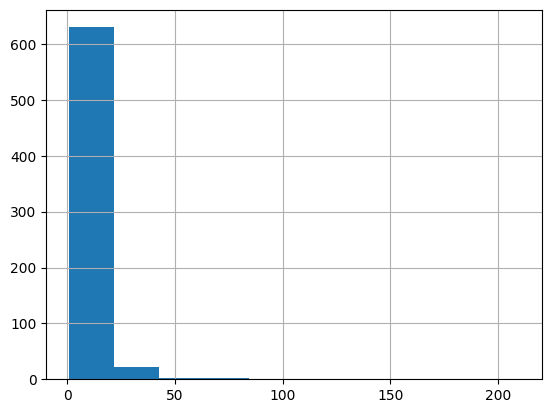

In [67]:
metadata["duration"].hist()

In [18]:
fig = px.histogram(metadata, x="duration", title="Distribution of duration (seconds)")
fig.write_image("duration_hist.png")
fig.show()

### Saving metadata

In [46]:
metadata.to_csv("metadata.csv", index=False)

# Adding extra data from CDC survey 2020

In [1]:
from sklearn.preprocessing import LabelEncoder

### Constants

In [7]:
PKIHD: Path = DATA_DIR / "PKIHD/heart_2020_cleaned.csv"

### Reading

In [8]:
questionnaire_df = pd.read_csv(PKIHD)
print(questionnaire_df.info())
questionnaire_df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No
5,Yes,28.87,Yes,No,No,6.0,0.0,Yes,Female,75-79,Black,No,No,Fair,12.0,No,No,No
6,No,21.63,No,No,No,15.0,0.0,No,Female,70-74,White,No,Yes,Fair,4.0,Yes,No,Yes
7,No,31.64,Yes,No,No,5.0,0.0,Yes,Female,80 or older,White,Yes,No,Good,9.0,Yes,No,No
8,No,26.45,No,No,No,0.0,0.0,No,Female,80 or older,White,"No, borderline diabetes",No,Fair,5.0,No,Yes,No
9,No,40.69,No,No,No,0.0,0.0,Yes,Male,65-69,White,No,Yes,Good,10.0,No,No,No


### Unique categories

In [6]:
categorical = questionnaire_df.select_dtypes(["object"]) 
categorical.nunique().copy()

HeartDisease         2
Smoking              2
AlcoholDrinking      2
Stroke               2
DiffWalking          2
Sex                  2
AgeCategory         13
Race                 6
Diabetic             4
PhysicalActivity     2
GenHealth            5
Asthma               2
KidneyDisease        2
SkinCancer           2
dtype: int64

In [7]:
for column in categorical:
    print(f"{column} | {', '.join(questionnaire_df[column].unique())}")

HeartDisease | No, Yes
Smoking | Yes, No
AlcoholDrinking | No, Yes
Stroke | No, Yes
DiffWalking | No, Yes
Sex | Female, Male
AgeCategory | 55-59, 80 or older, 65-69, 75-79, 40-44, 70-74, 60-64, 50-54, 45-49, 18-24, 35-39, 30-34, 25-29
Race | White, Black, Asian, American Indian/Alaskan Native, Other, Hispanic
Diabetic | Yes, No, No, borderline diabetes, Yes (during pregnancy)
PhysicalActivity | Yes, No
GenHealth | Very good, Fair, Good, Poor, Excellent
Asthma | Yes, No
KidneyDisease | No, Yes
SkinCancer | Yes, No


### Encoding Binary Data

### Smoking

In [8]:
encoder = LabelEncoder()
questionnaire_df["Smoking"] = encoder.fit_transform(questionnaire_df["Smoking"])
questionnaire_df["Smoking"].head(5)

0    1
1    0
2    1
3    0
4    0
Name: Smoking, dtype: int64

### HeartDisease

In [9]:
encoder = LabelEncoder()
questionnaire_df["HeartDisease"] = encoder.fit_transform(questionnaire_df["HeartDisease"])
questionnaire_df["HeartDisease"].head(5) 

0    0
1    0
2    0
3    0
4    0
Name: HeartDisease, dtype: int64

### AlcoholDrinking

In [10]:
encoder = LabelEncoder()
questionnaire_df["AlcoholDrinking"] = encoder.fit_transform(questionnaire_df["AlcoholDrinking"])
questionnaire_df["AlcoholDrinking"].head(5)

0    0
1    0
2    0
3    0
4    0
Name: AlcoholDrinking, dtype: int64

In [11]:
encoder = LabelEncoder()
questionnaire_df["Stroke"] = encoder.fit_transform(questionnaire_df["Stroke"])
questionnaire_df["Stroke"].head(5)

0    0
1    1
2    0
3    0
4    0
Name: Stroke, dtype: int64

### DiffWalking

In [12]:
encoder = LabelEncoder()
questionnaire_df["DiffWalking"] = encoder.fit_transform(questionnaire_df["DiffWalking"])
questionnaire_df["DiffWalking"].head(5)

0    0
1    0
2    0
3    0
4    1
Name: DiffWalking, dtype: int64

### Sex

In [14]:
encoder = LabelEncoder()
questionnaire_df["Sex"] = encoder.fit_transform(questionnaire_df["Sex"])
questionnaire_df["Sex"].head(5)

0    0
1    0
2    1
3    0
4    0
Name: Sex, dtype: int64

### PhysicalActivity

In [16]:
encoder = LabelEncoder()
questionnaire_df["PhysicalActivity"] = encoder.fit_transform(questionnaire_df["PhysicalActivity"])
questionnaire_df["PhysicalActivity"].head(5)

0    1
1    1
2    1
3    0
4    1
Name: PhysicalActivity, dtype: int64

### Asthma

In [18]:
encoder = LabelEncoder()
questionnaire_df["Asthma"] = encoder.fit_transform(questionnaire_df["Asthma"])
questionnaire_df["Asthma"].head(5)

0    1
1    0
2    1
3    0
4    0
Name: Asthma, dtype: int64

### KidneyDisease 

In [20]:
encoder = LabelEncoder()
questionnaire_df["KidneyDisease"] = encoder.fit_transform(questionnaire_df["KidneyDisease"])
questionnaire_df["KidneyDisease"].head(5)

0    0
1    0
2    0
3    0
4    0
Name: KidneyDisease, dtype: int64

### SkinCancer

In [22]:
encoder = LabelEncoder()
questionnaire_df["SkinCancer"] = encoder.fit_transform(questionnaire_df["SkinCancer"])
questionnaire_df["SkinCancer"].head(5)

0    1
1    0
2    0
3    1
4    0
Name: SkinCancer, dtype: int64

checking 

In [24]:
questionnaire_df.head(5)

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,1,0,0,3.0,30.0,0,0,55-59,White,Yes,1,Very good,5.0,1,0,1
1,0,20.34,0,0,1,0.0,0.0,0,0,80 or older,White,No,1,Very good,7.0,0,0,0
2,0,26.58,1,0,0,20.0,30.0,0,1,65-69,White,Yes,1,Fair,8.0,1,0,0
3,0,24.21,0,0,0,0.0,0.0,0,0,75-79,White,No,0,Good,6.0,0,0,1
4,0,23.71,0,0,0,28.0,0.0,1,0,40-44,White,No,1,Very good,8.0,0,0,0


### Encoding Multy label Data

### AgeCategory

In [31]:
AGE_CATEGORY = {
    "18-24": 0,
    "25-29": 1,
    "30-34": 2,
    "35-39": 3,
    "40-44": 4,
    "45-49": 5,
    "50-54": 6,
    "55-59": 7,
    "60-64": 8,
    "65-69": 9,
    "70-74": 10,
    "75-79": 11,
    "80 or older": 12
} 

age_encoding = lambda x: AGE_CATEGORY[x]
questionnaire_df["AgeCategory"] = questionnaire_df["AgeCategory"].apply(age_encoding)
questionnaire_df.head(5)

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,1,0,0,3.0,30.0,0,0,7,White,Yes,1,Very good,5.0,1,0,1
1,0,20.34,0,0,1,0.0,0.0,0,0,12,White,No,1,Very good,7.0,0,0,0
2,0,26.58,1,0,0,20.0,30.0,0,1,9,White,Yes,1,Fair,8.0,1,0,0
3,0,24.21,0,0,0,0.0,0.0,0,0,11,White,No,0,Good,6.0,0,0,1
4,0,23.71,0,0,0,28.0,0.0,1,0,4,White,No,1,Very good,8.0,0,0,0


### Race

In [32]:
questionnaire_df["Race"].unique()

array(['White', 'Black', 'Asian', 'American Indian/Alaskan Native',
       'Other', 'Hispanic'], dtype=object)

In [36]:
RACE_CATEGORY = {
    "White": 0,
    "Black": 1,
    "Asian": 2,
    "American Indian/Alaskan Native": 3,
    "Other": 4,
    "Hispanic": 5
}

race_encoding = lambda x: RACE_CATEGORY[x]
questionnaire_df["Race"] = questionnaire_df["Race"].apply(race_encoding)
questionnaire_df.head(15)

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,1,0,0,3.0,30.0,0,0,7,0,Yes,1,Very good,5.0,1,0,1
1,0,20.34,0,0,1,0.0,0.0,0,0,12,0,No,1,Very good,7.0,0,0,0
2,0,26.58,1,0,0,20.0,30.0,0,1,9,0,Yes,1,Fair,8.0,1,0,0
3,0,24.21,0,0,0,0.0,0.0,0,0,11,0,No,0,Good,6.0,0,0,1
4,0,23.71,0,0,0,28.0,0.0,1,0,4,0,No,1,Very good,8.0,0,0,0
5,1,28.87,1,0,0,6.0,0.0,1,0,11,1,No,0,Fair,12.0,0,0,0
6,0,21.63,0,0,0,15.0,0.0,0,0,10,0,No,1,Fair,4.0,1,0,1
7,0,31.64,1,0,0,5.0,0.0,1,0,12,0,Yes,0,Good,9.0,1,0,0
8,0,26.45,0,0,0,0.0,0.0,0,0,12,0,"No, borderline diabetes",0,Fair,5.0,0,1,0
9,0,40.69,0,0,0,0.0,0.0,1,1,9,0,No,1,Good,10.0,0,0,0


### Diabetic

In [38]:
questionnaire_df["Diabetic"].unique()

array(['Yes', 'No', 'No, borderline diabetes', 'Yes (during pregnancy)'],
      dtype=object)

In [39]:
questionnaire_df["Diabetic"]

0         Yes
1          No
2         Yes
3          No
4          No
         ... 
319790    Yes
319791     No
319792     No
319793     No
319794     No
Name: Diabetic, Length: 319795, dtype: object

In [40]:
DIABETIC_CATEGORY = {
    "No": 0,
    "Yes": 1,
    "Yes (during pregnancy)": 2,
    "No, borderline diabetes": 3
}

diabetic_encoding = lambda x: DIABETIC_CATEGORY[x]
questionnaire_df["Diabetic"] = questionnaire_df["Diabetic"].apply(diabetic_encoding)
questionnaire_df.head(15)

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,1,0,0,3.0,30.0,0,0,7,0,1,1,Very good,5.0,1,0,1
1,0,20.34,0,0,1,0.0,0.0,0,0,12,0,0,1,Very good,7.0,0,0,0
2,0,26.58,1,0,0,20.0,30.0,0,1,9,0,1,1,Fair,8.0,1,0,0
3,0,24.21,0,0,0,0.0,0.0,0,0,11,0,0,0,Good,6.0,0,0,1
4,0,23.71,0,0,0,28.0,0.0,1,0,4,0,0,1,Very good,8.0,0,0,0
5,1,28.87,1,0,0,6.0,0.0,1,0,11,1,0,0,Fair,12.0,0,0,0
6,0,21.63,0,0,0,15.0,0.0,0,0,10,0,0,1,Fair,4.0,1,0,1
7,0,31.64,1,0,0,5.0,0.0,1,0,12,0,1,0,Good,9.0,1,0,0
8,0,26.45,0,0,0,0.0,0.0,0,0,12,0,3,0,Fair,5.0,0,1,0
9,0,40.69,0,0,0,0.0,0.0,1,1,9,0,0,1,Good,10.0,0,0,0


### GenHealth

In [42]:
questionnaire_df["GenHealth"].unique()

array(['Very good', 'Fair', 'Good', 'Poor', 'Excellent'], dtype=object)

In [46]:
GENHEALTH_CATEGORY = {
    "Excellent": 0,
    "Very good": 1,
    "Good": 2,
    "Fair": 3,
    "Poor": 4
}

genhealth_encoding = lambda x: GENHEALTH_CATEGORY[x]
questionnaire_df["GenHealth"] = questionnaire_df["GenHealth"].apply(genhealth_encoding)
questionnaire_df.head(15)

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,1,0,0,3.0,30.0,0,0,7,0,1,1,1,5.0,1,0,1
1,0,20.34,0,0,1,0.0,0.0,0,0,12,0,0,1,1,7.0,0,0,0
2,0,26.58,1,0,0,20.0,30.0,0,1,9,0,1,1,3,8.0,1,0,0
3,0,24.21,0,0,0,0.0,0.0,0,0,11,0,0,0,2,6.0,0,0,1
4,0,23.71,0,0,0,28.0,0.0,1,0,4,0,0,1,1,8.0,0,0,0
5,1,28.87,1,0,0,6.0,0.0,1,0,11,1,0,0,3,12.0,0,0,0
6,0,21.63,0,0,0,15.0,0.0,0,0,10,0,0,1,3,4.0,1,0,1
7,0,31.64,1,0,0,5.0,0.0,1,0,12,0,1,0,2,9.0,1,0,0
8,0,26.45,0,0,0,0.0,0.0,0,0,12,0,3,0,3,5.0,0,1,0
9,0,40.69,0,0,0,0.0,0.0,1,1,9,0,0,1,2,10.0,0,0,0


### Rename `HeartDisease` to `label` column

In [3]:
questionnaire_df.rename(columns={"HeartDisease": "label"}, inplace=True)
questionnaire_df.head(2)

,label,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,1,0,0,3.0,30.0,0,0,7,0,1,1,1,5.0,1,0,1
1,0,20.34,0,0,1,0.0,0.0,0,0,12,0,0,1,1,7.0,0,0,0


### Replace values in label
- 0 to normal
- 1 to abnormal

In [4]:
rename_target = lambda label: "abnormal" if label == 1 else "normal"
questionnaire_df["label"] = questionnaire_df["label"].apply(rename_target)
questionnaire_df.head(5)

,label,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,normal,16.60,1,0,0,3.0,30.0,0,0,7,0,1,1,1,5.0,1,0,1
1,normal,20.34,0,0,1,0.0,0.0,0,0,12,0,0,1,1,7.0,0,0,0
2,normal,26.58,1,0,0,20.0,30.0,0,1,9,0,1,1,3,8.0,1,0,0
3,normal,24.21,0,0,0,0.0,0.0,0,0,11,0,0,0,2,6.0,0,0,1
4,normal,23.71,0,0,0,28.0,0.0,1,0,4,0,0,1,1,8.0,0,0,0


### Saving

In [5]:
questionnaire_df.to_csv("CDC_survey_2020.csv", index=False) 
questionnaire_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   label             319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  int64  
 3   AlcoholDrinking   319795 non-null  int64  
 4   Stroke            319795 non-null  int64  
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  int64  
 8   Sex               319795 non-null  int64  
 9   AgeCategory       319795 non-null  int64  
 10  Race              319795 non-null  int64  
 11  Diabetic          319795 non-null  int64  
 12  PhysicalActivity  319795 non-null  int64  
 13  GenHealth         319795 non-null  int64  
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  int64  
 16  KidneyDisease     31